<h1><center>Workshop on Computer Vision for Image Segmentation</center></h1>

Prepared by **Vladimir PIMONOV**  
Affiliation: [ILM / Team PNEC]  
Contact: [foxlightmanstudes@gmail.com]

These notebooks were prepared for the workshop and are intended as guided practical material.  
They can also be used independently outside the workshop.  
For questions, feedback, or bug reports, please contact the author.

<h2><center>PW 02. Preparation of dataframe</center></h2>

In this notebook, we prepare the saved dataset description so it can be used in PyTorch for model training.

In the previous notebook, we created and exported the image patches, mask patches, and the dataframe describing the dataset split.  
Here, we use that information to build a proper training pipeline.

The main goals are:

1. define a custom PyTorch dataset,
2. define the transformations applied to images and masks,
3. load the dataframe containing the train, validation, and test split,
4. create datasets and dataloaders,
5. check visually that the augmentations and loaded samples behave as expected.

## 1. Import the required libraries

We begin by importing the packages needed for the data-loading pipeline.

These libraries will help us:

- read image and mask files,
- handle tabular data with pandas,
- define PyTorch datasets and dataloaders,
- apply image transformations,
- visualize samples and augmentations.

At this stage, the focus is not yet on the neural network itself.  
We are preparing the input pipeline that will feed the model during training.

In [16]:
import os
from os.path import join as pjoin
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'

import matplotlib.pyplot as plt

import pandas as pd

import tifffile
from tifffile import TiffFile

from PIL import Image, ImageOps

import numpy as np

import random

from torchvision.transforms import functional as TF

from tqdm.notebook import tqdm

import json
from pathlib import Path

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.utils.data

## 2. Define the dataset class used for training

PyTorch expects training data to be wrapped in a `Dataset` object.

This dataset class is responsible for loading the training samples from disk.

For each index, it performs the following steps:

1. build the path to the image file,
2. build the path to the corresponding mask file,
3. load both files,
4. convert the mask into a binary target,
5. apply the chosen transformations,
6. return the pair `(image, target)`.

This step is essential because, during training, the model never sees the whole dataframe directly.  
It only receives batches of `(image, mask)` pairs produced by the dataset and the dataloader.

A few points are worth noting:

- the mask is binarized with `mask != 0`, meaning that any nonzero annotated region is treated as foreground,
- the image remains grayscale,
- the transformations are applied after loading, so they can be randomized differently at each training epoch.

This means that the same saved patch may appear in slightly different augmented forms during training, which helps reduce overfitting.

In [2]:
class DS_NPs(torch.utils.data.Dataset):
    
    def __init__(self, root, img_arr, transforms=None):
        ### the dataset interrior values
        self.root = root
        self.transforms = transforms
        self.img_list = img_arr.values
        
    def __getitem__(self, idx):
        # load images and masks
        img_path = os.path.join(self.root, "Images", self.img_list[idx]+'.tiff')
        mask_path = os.path.join(self.root, "Masks", self.img_list[idx]+'.tiff')
        
        with TiffFile(mask_path) as tif:
            mask = tif.asarray()
            
        target = (mask!=0).astype(int) ### binarize the mask
            
        with TiffFile(img_path) as tif:
            img = tif.asarray()
        
        if self.transforms is not None:
            img, target = self.transforms(img, target)

        return img, target

    def __len__(self):
        return len(self.img_list)

## 3. Define the transformations used for the dataset

Here we define the transformation classes that will be used when loading the data.

In practice, a transformation is a small operation applied to a sample before it is passed to the model.  
Some transformations only change the **data format**, while others modify the **content of the image** in order to create more variety during training.

### 3.1. Format conversion transformations

These transformations change how the data is represented, without changing its meaning.

- **`ToTensor`** converts an image or a mask into a PyTorch tensor.  
  This is necessary because PyTorch models work with tensors, not with NumPy arrays or PIL images.

- **`ToPil`** converts a tensor or array back into a PIL image.  
  This can be useful because some image-processing operations are easier to apply in PIL format.

These conversions are technical but essential: they allow the same data to move between loading, preprocessing, visualization, and model input.

### 3.2. Geometric transformations

These transformations change the spatial arrangement of the image.

Examples used here include:

- **horizontal flip**,  
- **vertical flip**,  
- **one random flip chosen between horizontal and vertical**,  
- **rotation by 90°, 180°, or 270°**.

These operations do not change what the object is, but they change its orientation in the image.  
They are useful because they make the model less dependent on a specific direction or layout.

In segmentation, geometric transformations must always be applied to the **image and the mask together**, in exactly the same way.  
If the image is flipped or rotated but the mask is not, the annotation becomes wrong.

### 3.3. Intensity or photometric transformations

These transformations change the appearance of the image without changing its geometry.

Examples include:

- **brightness adjustment**,  
- **contrast adjustment**,  
- **gamma adjustment**,  
- and, in more general image pipelines, transformations such as hue or saturation changes.

These operations simulate variations in acquisition conditions, illumination, or contrast.  
They can help the model become more robust to differences between images.

Unlike geometric transformations, these intensity transformations are applied only to the **image**, not to the mask.  
The mask is not a measured signal: it is a label map. Its values should stay unchanged.

### 3.4. Why `Compose` is needed

In practice, we usually want to apply several transformations one after another.

For example, we may want to:

1. convert the sample to a tensor,
2. apply a random flip,
3. apply a random rotation,
4. then adjust brightness or contrast.

The `Compose` class is used to **chain several transformations into a single pipeline**.  
Instead of calling each transformation manually, we define a sequence once and then apply it to every sample in a consistent way.

This makes the code cleaner and ensures that the preprocessing and augmentation steps are always applied in the same order.

In [3]:
# 3.1. Format conversion transformations
class ToTensor(object):
    def __call__(self, image, target):
        image = TF.to_tensor(image)
        target = TF.to_tensor(target)
        return image, target
    
class ToPil(object):
    def __call__(self, image, target):
        image = TF.to_pil_image(image)
        return image, target

# 3.2. Geometric transformations
class RandomHorizontalFlip(object):
    def __init__(self, prob):
        self.prob = prob
        self._last_applied = False
        
    def __call__(self, image, target):
        self._last_applied = (random.random() < self.prob)
        if self._last_applied:
            height, width = image.shape[-2:]
            image = image.flip(-1)
            target = target.flip(-1)
        return image, target

class RandomVerticalFlip(object):
    def __init__(self, prob):
        self.prob = prob
        self._last_applied = False
        
    def __call__(self, image, target):
        self._last_applied = (random.random() < self.prob)
        if self._last_applied:
            height, width = image.shape[-2:]
            image = image.flip(-2)
            target = target.flip(-2)
        return image, target
    
class RandomOneOfFlip(object):
    """
    With probability f_a apply exactly one flip.
    If applied: vertical with probability p_v, else horizontal.
    """
    def __init__(self, f_a: float = 0.5, p_v: float = 0.5):
        self.f_a = float(f_a)   # probability that a flip is applied at all
        self.p_v = float(p_v)   # conditional probability of vertical given flip

    def __call__(self, image: torch.Tensor, target: torch.Tensor):
        if random.random() < self.f_a:
            if random.random() < self.p_v:
                # print('Vertical')
                image = image.flip(-2)   # vertical
                target = target.flip(-2)
            else:
                # print('Horizontal')
                image = image.flip(-1)   # horizontal
                target = target.flip(-1)
        return image, target

class RandomRightAngleRotate(object):
    """
    Rotate by {0, 90, 180, 270} degrees with equal probability.
    Applies the same rotation to image and target.
    """
    def __init__(self):
        self.k_choices = (0, 1, 2, 3)  # k * 90 degrees

    def __call__(self, image: torch.Tensor, target: torch.Tensor):
        k = random.choice(self.k_choices)
        if k != 0:
            # print(k)
            image = torch.rot90(image, k, dims=(-2, -1))
            target = torch.rot90(target, k, dims=(-2, -1))
        return image, target
    
# 3.3. Intensity or photometric transformations
class Adj_Brightness(object):
    def __init__(self, params, prob = 0.75):
        self.params = params
        self.prob = prob
    
    def __call__(self, image, target):
        if random.random() < self.prob:
            if type(self.params) == tuple:
                transformation_order = random.uniform(self.params[0], self.params[1])
            else:
                transformation_order = random.uniform(0, self.params)
            image = TF.adjust_brightness(image, transformation_order)
        
        return image, target

class Adj_Contrast(object):
    def __init__(self, params, prob = 0.75):
        self.params = params
        self.prob = prob
    
    def __call__(self, image, target):
        if random.random() < self.prob:
            if type(self.params) == tuple:
                transformation_order = random.uniform(self.params[0], self.params[1])
            else:
                transformation_order = random.uniform(0, self.params)
            image = TF.adjust_contrast(image, transformation_order)
            
        return image, target

class Adj_Gamma(object):
    def __init__(self, gain, params, prob = 0.75):
        self.gain = gain
        self.params = params
        self.prob = prob
    
    def __call__(self, image, target):
        if random.random() < self.prob:
            if type(self.params) == tuple:
                transformation_order = random.uniform(self.params[0], self.params[1])
            else:
                transformation_order = random.uniform(0, self.params)
            
            if type(self.gain) == tuple:
                gain_order = random.uniform(self.gain[0], self.gain[1])
            else:
                gain_order = random.uniform(0, self.gain)
            image = TF.adjust_gamma(image, transformation_order, gain_order)
            
        return image, target
    
class Adj_Hue(object):
    def __init__(self, params, prob = 0.75):
        self.params = params
        self.prob = prob
    
    def __call__(self, image, target):
        if random.random() < self.prob:
            if type(self.params) == tuple:
                transformation_order = random.uniform(self.params[0], self.params[1])
            else:
                transformation_order = random.uniform(-0.5, self.params)
            image = TF.adjust_hue(image, transformation_order)
            
        return image, target
    
class Adj_Saturation(object):
    def __init__(self, params, prob = 0.75):
        self.params = params
        self.prob = prob
    
    def __call__(self, image, target):
        if random.random() < self.prob:
            if type(self.params) == tuple:
                transformation_order = random.uniform(self.params[0], self.params[1])
            else:
                transformation_order = random.uniform(-0.5, self.params)
            image = TF.adjust_saturation(image, transformation_order)
            
        return image, target
    
# 3.4. Chain transformations
class Compose(object):
    def __init__(self, transforms):
        self.transforms = transforms

    def __call__(self, image, target):
        for t in self.transforms:
            image, target = t(image, target)
        return image, target

## 4. Define the augmentation pipeline used during training

This function specifies how each sample is preprocessed before being sent to the model.

### Why do we need a transformation pipeline?

Raw images stored on disk are not yet in the form expected by PyTorch.  
In addition, for training, we usually want to introduce controlled random variations in order to make the model more robust.

The transformation pipeline therefore has two roles:

- **format conversion**, so that the data can be used by the model,
- **data augmentation**, so that the model learns from a more diverse set of examples.

### Step 1. Convert the sample to tensors

The first operation is `ToTensor()`.

PyTorch models work with tensors, not with TIFF arrays or PIL images.  
This step converts both the image and the mask into tensor form.

### Step 2. Apply training augmentations

When `train=True`, several random augmentations are added:

- a random flip,
- a right-angle rotation,
- a brightness adjustment,
- a contrast adjustment.

These augmentations have different purposes:

#### Geometric augmentations
Flips and rotations change the spatial arrangement of the image.

They help the model become less dependent on a particular orientation.  
For example, if a structure can appear in several directions, the model should not learn that only one orientation is valid.

For segmentation, these transformations must always be applied to the **image and the mask together**, otherwise the supervision would become incorrect.

#### Photometric augmentations
Brightness and contrast changes modify the visual appearance of the image without changing its geometry.

They help the model become more robust to acquisition differences such as:

- illumination changes,
- detector response changes,
- contrast variations between microscopy sessions.

These transformations are applied only to the **image**, not to the **mask**, because the mask is a label map rather than a measured intensity image.

### Why do we disable these augmentations for validation and test?

For validation and test, we want the evaluation to be stable and reproducible.  
So we keep only the essential conversion steps and avoid random modifications.

This ensures that any change in validation performance reflects the model itself rather than random augmentation noise.

In [4]:
def get_transform(train):
    transforms = []
    # converts the image, a PIL image, into a PyTorch Tensor
    transforms.append(ToTensor())
    if train:
        # during training, randomly flip the training images
        # and ground-truth for data augmentation
        transforms.append(RandomOneOfFlip(0.5, 0.5))
        transforms.append(RandomRightAngleRotate())
        transforms.append(Adj_Brightness((0.5,1.5), 0.5))
        transforms.append(Adj_Contrast((0.5,4), 0.5))

        # cluster of transformations applicable only to PIL images
        # so first and last transformations are indispensable
        # however we won't use any of these transformations because our images are grayscale
        # transforms.append(T.ToPil()) # Not needed
        # transforms.append(T.Adj_Gamma((0.5,1.5),(1,2.5), 0.5)) # Not needed
        # transforms.append(T.Adj_Hue((-0.5,0.5),1)) Not needed
        # transforms.append(T.Adj_Saturation((0,3))) # not needed because we have grayscale images
        # transforms.append(T.ToTensor()) # Not needed

    return Compose(transforms)

## 5. Define how samples are grouped into a batch

The dataloader will collect several samples at once and combine them into a batch.

This custom `collate_fn` simply groups the loaded images and targets into tuples.  
That is enough for our pipeline, because the conversion into stacked tensors will be handled later during training.

Keeping the collation step simple is often convenient in segmentation workflows, especially when working with paired data such as images and masks.

In [5]:
def collate_fn(batch):
    return tuple(zip(*batch))

## 6. Define the dataset location on disk

Here we specify the folder where the exported image and mask patches are stored.

The dataset class will use this root folder to find the corresponding files inside the `Images` and `Masks` subfolders.

In [22]:
root = r'Agregates for training TP\Training 512 TP'

## 7. Load the dataframe describing the dataset split

Now we load the dataframe prepared earlier.

This table contains the list of exported patch names and tells us which samples belong to:

- the training set,
- the validation set,
- the test set.

In other words, this dataframe is the bridge between the dataset preparation notebook and the training notebook.  
It tells the code exactly which saved patches must be loaded for each part of the workflow.

In [23]:
df_paths = pd.read_csv(pjoin(root, r'Whole Training set 512.csv'), sep="\t", index_col=0)

## 8. Create the datasets and dataloaders

Using the dataset class and the dataframe split, we now create three datasets:

- a **training dataset**,
- a **validation dataset**,
- a **test dataset**.

Then each dataset is wrapped into a **dataloader**.

### What is the role of a dataset?

A dataset knows how to load **one sample at a time**.  
It answers the question: *if I ask for item `i`, which image and which mask should I return?*

### What is the role of a dataloader?

A dataloader knows how to:

- iterate over the dataset,
- group several samples into mini-batches,
- optionally shuffle the order of the samples.

Mini-batch training is important because neural networks are rarely trained on the whole dataset at once.  
Instead, they are trained on many small batches, which is computationally efficient and introduces useful stochasticity.

### Why is `shuffle=True` used?

For training, shuffling prevents the network from always seeing samples in the same order.  
This usually improves optimization and avoids unwanted ordering effects.

For validation and test, shuffling is less important for the metric itself, but keeping the dataloader format similar makes the pipeline simpler.

### What is `num_workers`?

The `num_workers` parameter controls how many separate worker processes are used to load data in parallel.

When `num_workers=0`, the dataloader loads samples in the main Python process, one batch at a time.  
When `num_workers>0`, PyTorch can prepare future batches in parallel while the model is training on the current one.

Using several workers can make data loading faster, especially when:

- the dataset is large,
- file reading is slow,
- many transformations must be applied on the fly.

However, in notebook-based workflows, and especially on Windows, multi-process loading can sometimes create practical issues such as crashes, freezing, or worker initialization errors.

For that reason, `num_workers=0` is often the safest choice for teaching notebooks and for portable code examples.  
It may not be the fastest setting, but it is usually the most stable and the easiest to debug.

In [25]:
# use our dataset and defined transformations
dataset = DS_NPs(root, df_paths[df_paths['Usage']=='tr']['Patch_name'], get_transform(train=True))
dataset_val = DS_NPs(root, df_paths[df_paths['Usage']=='val']['Patch_name'], get_transform(train=False))
dataset_test = DS_NPs(root, df_paths[df_paths['Usage']=='test']['Patch_name'], get_transform(train=False))

# define training and validation data loaders
data_loader = torch.utils.data.DataLoader(
        dataset, batch_size=4, shuffle=True, num_workers=0,
    collate_fn=collate_fn)

# define training and validation data loaders
data_loader_val = torch.utils.data.DataLoader(
        dataset_val, batch_size=4, shuffle=True, num_workers=0,
    collate_fn=collate_fn)

# define training and validation data loaders
data_loader_test = torch.utils.data.DataLoader(
        dataset_test, batch_size=4, shuffle=True, num_workers=0,
    collate_fn=collate_fn)

## 9. Visualize the effect of the training augmentations

Here we illustrate how the main augmentations used in the training pipeline affect a sample.

We separate them into two groups:

### 1. Geometric transformations
These change the spatial arrangement of the data:

- rotation by 90°, 180°, and 270°,
- horizontal flip,
- vertical flip.

For segmentation, these transformations must always be applied to the **image and the mask together**, because the mask must stay aligned with the structures visible in the image. By comparing the image and mask pairs, we can clearly see that geometric transformations change the orientation of both.

### 2. Photometric transformations
These change only the visual appearance of the image:

- brightness adjustment,
- contrast adjustment.

These transformations are applied only to the **image**, not to the mask, because the mask is a label map rather than a measured intensity signal. By comparing the image and mask rows, we can notice that the mask remains unchanged while only the image appearance is modified.

This type of visualization is useful for two reasons:

- it confirms that the augmentation pipeline behaves correctly for segmentation,
- it helps estimate reasonable ranges for photometric transformations before training.

If the chosen brightness or contrast range is too weak, the augmentation may have little practical effect.  
If it is too strong, the transformed images may become unrealistic and make training less stable.

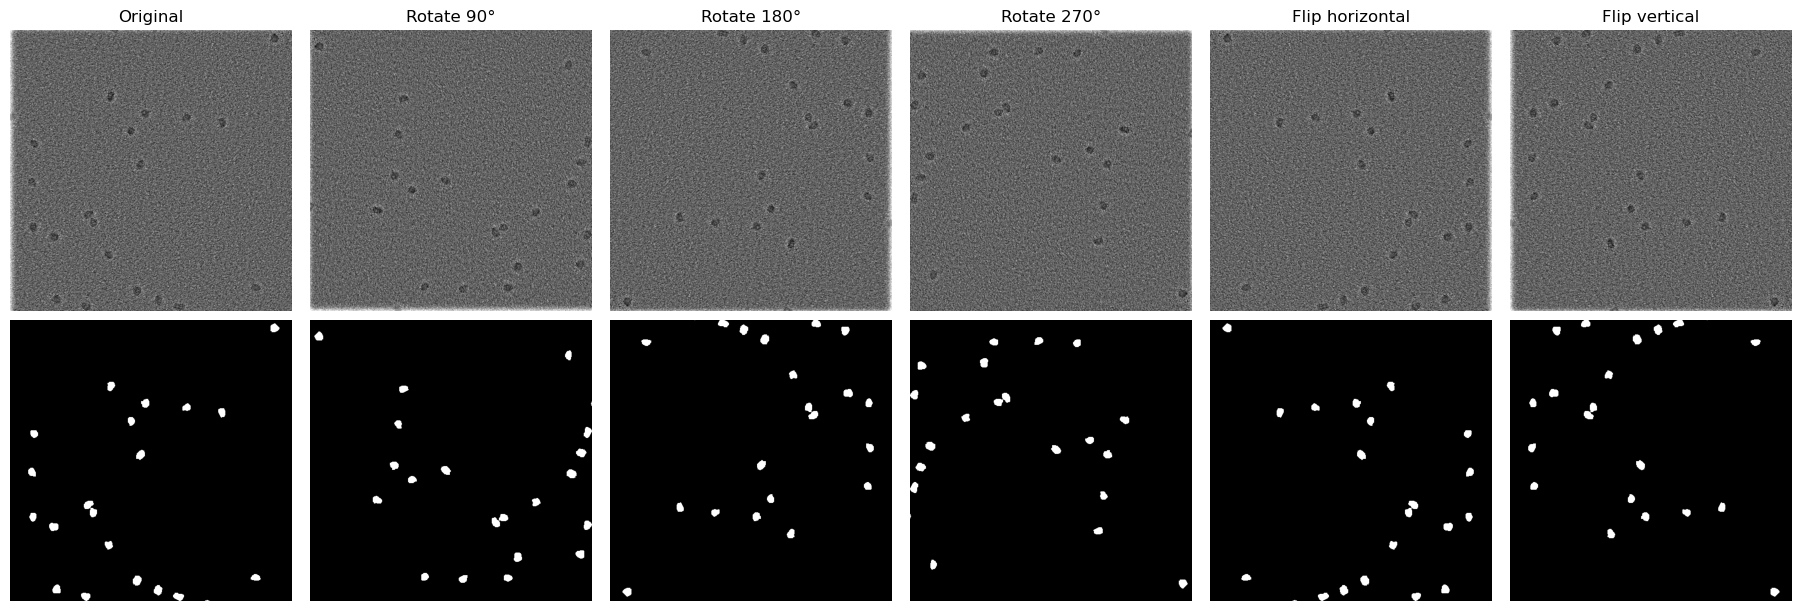

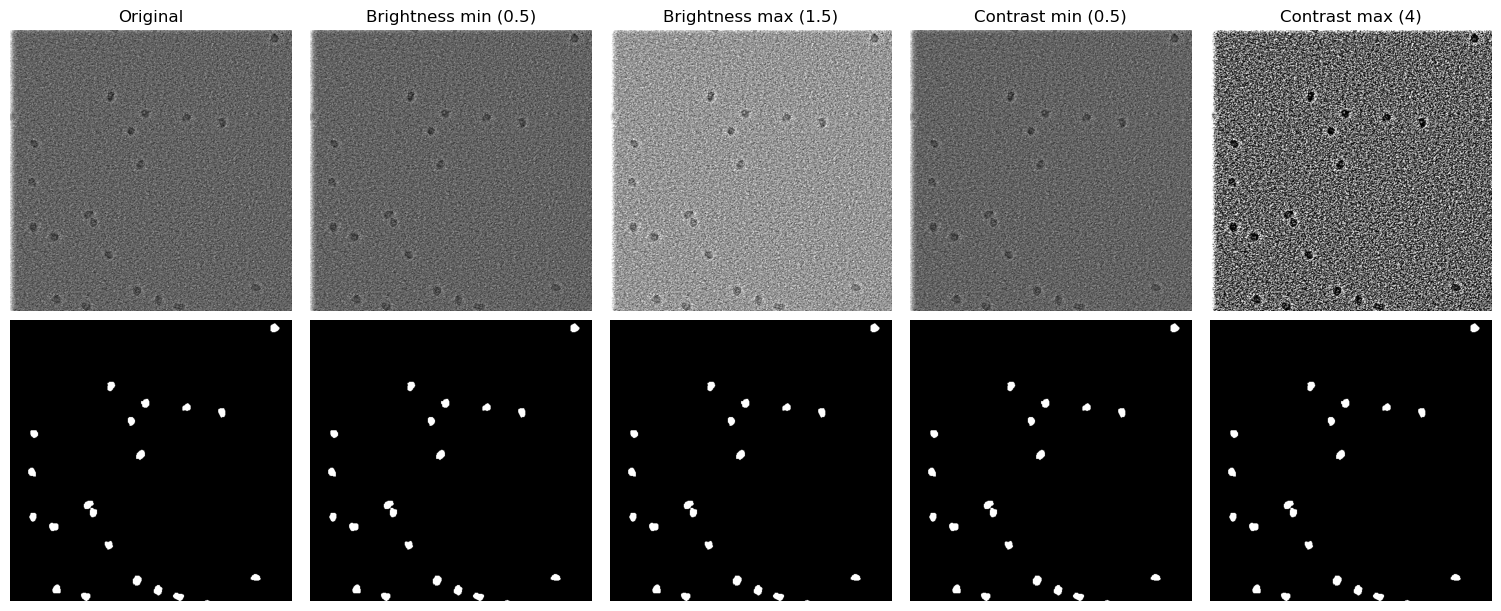

In [31]:
# 9.1 Load the dataframe and select one NON-EMPTY patch
base_patch_size = 512
csv_path = pjoin(root, f"Whole Training set {base_patch_size}.csv")

img_save_path = pjoin(root, "Image")
mask_save_path = pjoin(root, "Mask")

df_paths = pd.read_csv(csv_path, sep="\t", index_col=0)

# keep only exported samples if needed
if "Usage" in df_paths.columns:
    df_paths = df_paths[~df_paths["Usage"].isna()].copy()

# select one clearly non-empty patch
row_non_empty = df_paths[(df_paths["Empty"] == False) & (df_paths["Almost_Empty"] == False)].sample().iloc[0]
patch_name = row_non_empty["Patch_name"]

img = tifffile.imread(pjoin(img_save_path, patch_name + ".tiff"))
mask = tifffile.imread(pjoin(mask_save_path, patch_name + ".tiff"))

# convert to tensors for geometric transforms
img_t = TF.to_tensor(img)
mask_t = TF.to_tensor(mask)

# 9.2 Geometric transformations

geo_examples = [
    ("Original", img_t, mask_t),
    ("Rotate 90°",  torch.rot90(img_t, 1, dims=(-2, -1)), torch.rot90(mask_t, 1, dims=(-2, -1))),
    ("Rotate 180°", torch.rot90(img_t, 2, dims=(-2, -1)), torch.rot90(mask_t, 2, dims=(-2, -1))),
    ("Rotate 270°", torch.rot90(img_t, 3, dims=(-2, -1)), torch.rot90(mask_t, 3, dims=(-2, -1))),
    ("Flip horizontal", img_t.flip(-1), mask_t.flip(-1)),
    ("Flip vertical",   img_t.flip(-2), mask_t.flip(-2)),
]

fig, axes = plt.subplots(
    nrows=2,
    ncols=len(geo_examples),
    figsize=(3 * len(geo_examples), 6),
    constrained_layout=True
)

for col, (title, img_ex, mask_ex) in enumerate(geo_examples):
    axes[0, col].imshow(img_ex.squeeze().cpu().numpy(), cmap="gray")
    axes[0, col].set_title(title)
    axes[0, col].axis("off")

    axes[1, col].imshow(mask_ex.squeeze().cpu().numpy(), cmap="gray")
    axes[1, col].axis("off")

axes[0, 0].set_ylabel("Image", fontsize=12)
axes[1, 0].set_ylabel("Mask", fontsize=12)
plt.show()

# 9.3 Photometric transformations
# Use the augmentation classes with prob=1 and fixed min/max values

# You can change the values below to test the limits of the transformations
# and adapt them for the training data
brightness_min = 0.5
brightness_max = 1.5
contrast_min = 0.5
contrast_max = 4

# force the augmentation classes to use fixed values
bright_min_aug = Adj_Brightness((brightness_min, brightness_min), prob=1.0)
bright_max_aug = Adj_Brightness((brightness_max, brightness_max), prob=1.0)

contr_min_aug = Adj_Contrast((contrast_min, contrast_min), prob=1.0)
contr_max_aug = Adj_Contrast((contrast_max, contrast_max), prob=1.0)

img_bright_min, _ = bright_min_aug(img_t, mask_t)
img_bright_max, _ = bright_max_aug(img_t, mask_t)
img_contr_min, _ = contr_min_aug(img_t, mask_t)
img_contr_max, _ = contr_max_aug(img_t, mask_t)

photo_examples = [
    ("Original", img_t),
    (f"Brightness min ({brightness_min})", img_bright_min),
    (f"Brightness max ({brightness_max})", img_bright_max),
    (f"Contrast min ({contrast_min})", img_contr_min),
    (f"Contrast max ({contrast_max})", img_contr_max),
]

fig, axes = plt.subplots(
    nrows=2,
    ncols=len(photo_examples),
    figsize=(3 * len(photo_examples), 6),
    constrained_layout=True
)

for col, (title, img_ex) in enumerate(photo_examples):
    axes[0, col].imshow(img_ex.squeeze().cpu().numpy(), cmap="gray")
    axes[0, col].set_title(title)
    axes[0, col].axis("off")

    # mask stays unchanged for photometric transforms
    axes[1, col].imshow(mask_t.squeeze().cpu().numpy(), cmap="gray")
    axes[1, col].axis("off")

axes[0, 0].set_ylabel("Image", fontsize=12)
axes[1, 0].set_ylabel("Mask", fontsize=12)
plt.show()

## What we achieved in this notebook

In this notebook, we converted the saved dataset description into a PyTorch-ready data pipeline.

More precisely, we:

- defined a custom segmentation dataset,
- defined the transformation and augmentation rules,
- loaded the dataframe containing the train, validation, and test split,
- created the corresponding datasets and dataloaders,
- checked visually that the loaded samples and augmentations behave correctly.

An important point is that the transformations defined here are not specific to this one notebook.  
They are general data-loading and augmentation tools that can be reused with other image datasets as well, as long as the same logic of paired image and mask processing is needed.

For that reason, in the next practical work we will no longer define them explicitly inside the notebook.  
Instead, we will place them in a separate `.py` library file and simply import them when needed.

This makes the code cleaner, avoids repetition, and keeps the notebook focused on the training workflow rather than on rewriting utility functions each time.

The next step will be to connect this data pipeline to a segmentation model and start training.